In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

repo_root = Path.cwd().parent
sys.path.append(str(repo_root))

import src.utils.config as config
import src.utils.pdata_io as pdio

data_root, pdata_root, cc_data = pdio.load_project_context()

print(data_root)
print(pdata_root)
print("Number of animals:", len(cc_data))

/home/nmldata2/ccaw/Python
[LOADED] Project context: /mnt/pdata/Classical_Conditioning/_cache/project_context.pkl
/mnt/data/Classical_Conditioning
/mnt/pdata/Classical_Conditioning
Number of animals: 5


In [2]:
from src.qc.qc_behavior import check_recording_durations

duration_df = check_recording_durations(
    cc_data,
    target_duration_s=1200,
    tolerance_s=30
)

Recording duration summary
Target duration: 1200 s
Tolerance: ±30 s

Total sessions checked: 272
Sessions near target: 22
Sessions outside target: 250



,phase,n_sessions,mean_duration_s,min_duration_s,max_duration_s,n_near_target
0,air_training,81,1268.770886,6.7,2080.5,8
1,habituation,86,1336.067442,1155.0,2545.7,5
2,tone_air_training,50,1237.908000,231.7,1320.1,9
3,unknown,55,NaN,NaN,NaN,0


In [3]:

problem_sessions = duration_df[
    (~duration_df["near_target"]) & 
    (duration_df["status"] == "ok")
].copy()

problem_sessions = problem_sessions.sort_values(
    "duration_from_samples_s"
)

problem_sessions[
    [
        "animal",
        "date",
        "phase",
        "duration_from_samples_s",
        "duration_from_t_s",
        "duration_error_s",
        "status"
    ]
]

,animal,date,phase,duration_from_samples_s,duration_from_t_s,duration_error_s,status
166,NML_07,2026_03_04,air_training,6.7,6.699800,-1193.3,ok
199,NML_07,2026_03_18,tone_air_training,231.7,231.699799,-968.3,ok
228,NML_08,2026_03_08,air_training,761.2,761.199829,-438.8,ok
36,NML_04,2026_02_02,tone_air_training,1099.8,1099.799805,-100.2,ok
181,NML_07,2026_02_09,habituation,1155.0,1154.999756,-45.0,ok
...,...,...,...,...,...,...,...
18,NML_04,2025_12_30,habituation,1624.2,1624.199829,424.2,ok
122,NML_06,2025_12_30,habituation,1813.4,1813.399780,613.4,ok
57,NML_05,2026_01_17,air_training,2080.5,2080.499756,880.5,ok
128,NML_06,2026_01_05,habituation,2345.4,2345.399902,1145.4,ok


In [4]:
short_sessions = duration_df[
    (duration_df["status"] == "ok") &
    (duration_df["duration_from_samples_s"] < 1200)
].copy()

short_sessions = short_sessions.sort_values(
    ["phase", "animal", "date"]
).reset_index(drop=True)

short_sessions[
    [
        "animal",
        "date",
        "phase",
        "duration_from_samples_s",
        "duration_from_t_s",
        "status"
    ]
]



,animal,date,phase,duration_from_samples_s,duration_from_t_s,status
0,NML_07,2026_03_02,air_training,1175.2,1175.199829,ok
1,NML_07,2026_03_04,air_training,6.7,6.699800,ok
2,NML_08,2026_03_04,air_training,1180.3,1180.299805,ok
3,NML_08,2026_03_08,air_training,761.2,761.199829,ok
4,NML_07,2026_02_09,habituation,1155.0,1154.999756,ok
5,NML_04,2026_02_02,tone_air_training,1099.8,1099.799805,ok
6,NML_07,2026_03_18,tone_air_training,231.7,231.699799,ok


In [3]:
from src.qc.qc_events import check_all_event_consistency

events_all, event_qc = check_all_event_consistency(
    cc_data,
    tolerance_s=2.0,
    phase_filter=["habituation", "air_training","tone_air_training"]
)

event_qc

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/nmldata2/ccaw/Python/src/qc/qc_events.py:124: RuntimeWarning: All-NaN axis encountered
  min_off = float(np.nanmin(event_df["off_interval_to_next_on_s"]))
/home/nmldata2/ccaw/Python/src/qc/qc_events.py:125: RuntimeWarning: All-NaN axis encountered
  max_off = float(np.nanmax(event_df["off_interval_to_next_on_s"]))
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/nmldata2/ccaw/Python/src/qc/qc_events.py:124: RuntimeWarning: All-NaN axis encountered
  min_off = float(np.nanmin(event_df["off_interval_to_next_on_s"]))
/home/nmldata2/ccaw/Python/src/qc/qc_events.py:125: RuntimeWarning: All-NaN axis encounte

,animal,date,phase,n_onsets,n_offsets,n_pairs,signal_starts_on,signal_ends_on,n_invalid_pairs,n_bad_on_duration,n_bad_off_interval,median_on_duration_s,median_off_interval_s,min_on_duration_s,max_on_duration_s,min_off_interval_s,max_off_interval_s,needs_inspection,status
0,NML_04,2026_01_12,air_training,59.0,59.0,59.0,True,False,0.0,0.0,0.0,5.500183,15.086182,1.013794,24.622406,15.085571,15.087585,True,ok
1,NML_04,2026_01_13,air_training,55.0,55.0,55.0,False,False,0.0,0.0,0.0,4.739624,15.086395,1.304199,70.148392,15.085403,15.087402,False,ok
2,NML_04,2026_01_14,air_training,59.0,59.0,59.0,False,False,0.0,0.0,0.0,7.715820,15.086380,2.013000,80.321594,15.085403,15.087402,False,ok
3,NML_04,2026_01_15,air_training,60.0,60.0,60.0,False,False,0.0,0.0,1.0,5.750458,15.086426,2.437790,9.838562,15.085594,24.954395,True,ok
4,NML_04,2026_01_16,air_training,64.0,64.0,64.0,False,True,0.0,0.0,0.0,3.727966,15.086426,1.250397,23.727905,15.085571,15.087585,True,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,NML_08,2026_03_17,tone_air_training,48.0,48.0,48.0,False,False,0.0,0.0,47.0,8.058365,17.983826,2.678000,10.770752,17.983215,17.985413,True,ok
213,NML_08,2026_03_18,tone_air_training,51.0,51.0,51.0,False,False,0.0,0.0,50.0,6.525024,17.983597,2.141000,7.520020,17.982986,17.985001,True,ok
214,NML_08,2026_03_19,tone_air_training,50.0,50.0,50.0,False,False,0.0,0.0,49.0,6.901276,17.983582,2.270399,8.013184,17.982971,17.984863,True,ok
215,NML_08,2026_03_20,tone_air_training,48.0,48.0,48.0,False,False,0.0,0.0,47.0,7.762901,17.983398,2.045801,10.787994,17.982788,17.984619,True,ok


In [4]:
event_qc[event_qc["needs_inspection"]]

,animal,date,phase,n_onsets,n_offsets,n_pairs,signal_starts_on,signal_ends_on,n_invalid_pairs,n_bad_on_duration,n_bad_off_interval,median_on_duration_s,median_off_interval_s,min_on_duration_s,max_on_duration_s,min_off_interval_s,max_off_interval_s,needs_inspection,status
0,NML_04,2026_01_12,air_training,59.0,59.0,59.0,True,False,0.0,0.0,0.0,5.500183,15.086182,1.013794,24.622406,15.085571,15.087585,True,ok
3,NML_04,2026_01_15,air_training,60.0,60.0,60.0,False,False,0.0,0.0,1.0,5.750458,15.086426,2.437790,9.838562,15.085594,24.954395,True,ok
4,NML_04,2026_01_16,air_training,64.0,64.0,64.0,False,True,0.0,0.0,0.0,3.727966,15.086426,1.250397,23.727905,15.085571,15.087585,True,ok
22,NML_05,2026_01_20,air_training,10.0,10.0,10.0,False,True,0.0,0.0,0.0,14.333199,15.086599,7.809002,403.210815,15.085800,15.087036,True,ok
25,NML_05,2026_01_23,air_training,19.0,19.0,19.0,False,True,0.0,0.0,0.0,7.856800,15.086098,3.840698,349.866394,15.085388,15.087402,True,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,NML_08,2026_03_17,tone_air_training,48.0,48.0,48.0,False,False,0.0,0.0,47.0,8.058365,17.983826,2.678000,10.770752,17.983215,17.985413,True,ok
213,NML_08,2026_03_18,tone_air_training,51.0,51.0,51.0,False,False,0.0,0.0,50.0,6.525024,17.983597,2.141000,7.520020,17.982986,17.985001,True,ok
214,NML_08,2026_03_19,tone_air_training,50.0,50.0,50.0,False,False,0.0,0.0,49.0,6.901276,17.983582,2.270399,8.013184,17.982971,17.984863,True,ok
215,NML_08,2026_03_20,tone_air_training,48.0,48.0,48.0,False,False,0.0,0.0,47.0,7.762901,17.983398,2.045801,10.787994,17.982788,17.984619,True,ok


In [3]:
from src.qc.qc_events import check_all_event_consistency

events_H, qc_H = check_all_event_consistency(
    cc_data,
    phase_filter="habituation",
    tolerance_s=2.0
)

qc_H[qc_H["needs_inspection"]]

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/nmldata2/ccaw/Python/src/qc/qc_events.py:124: RuntimeWarning: All-NaN axis encountered
  min_off = float(np.nanmin(event_df["off_interval_to_next_on_s"]))
/home/nmldata2/ccaw/Python/src/qc/qc_events.py:125: RuntimeWarning: All-NaN axis encountered
  max_off = float(np.nanmax(event_df["off_interval_to_next_on_s"]))
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/nmldata2/ccaw/Python/src/qc/qc_events.py:124: RuntimeWarning: All-NaN axis encountered
  min_off = float(np.nanmin(event_df["off_interval_to_next_on_s"]))
/home/nmldata2/ccaw/Python/src/qc/qc_events.py:125: RuntimeWarning: All-NaN axis encounte

,animal,date,phase,n_onsets,n_offsets,n_pairs,signal_starts_on,signal_ends_on,n_invalid_pairs,n_bad_on_duration,n_bad_off_interval,median_on_duration_s,median_off_interval_s,min_on_duration_s,max_on_duration_s,min_off_interval_s,max_off_interval_s,needs_inspection,status
0,NML_04,2025_12_27,habituation,42,42,42,False,False,0.0,1.0,0.0,14.984467,14.984802,1.510376,14.985413,14.984558,14.985809,True,ok
6,NML_04,2026_01_02,habituation,41,41,41,False,True,1.0,0.0,0.0,14.984436,14.985321,14.984375,14.985596,14.984589,14.985962,True,ok
8,NML_04,2026_01_04,habituation,41,41,41,False,False,0.0,1.0,0.0,14.984589,14.985413,7.767578,14.985611,14.984741,14.986023,True,ok
11,NML_04,2026_01_07,habituation,42,42,42,False,True,1.0,0.0,0.0,14.984436,14.985596,14.984192,14.985474,14.984558,14.985840,True,ok
15,NML_04,2026_01_11,habituation,43,43,43,False,True,0.0,1.0,0.0,14.984200,14.985374,1.237793,14.985229,14.984375,14.985657,True,ok
17,NML_05,2025_12_28,habituation,41,41,41,False,False,0.0,1.0,0.0,14.984497,14.984802,12.522095,14.985474,14.984558,14.985840,True,ok
18,NML_05,2025_12_29,habituation,41,41,41,False,False,0.0,1.0,0.0,14.984375,14.985199,2.994629,14.985413,14.984558,14.985809,True,ok
21,NML_05,2026_01_01,habituation,46,46,46,False,False,0.0,1.0,0.0,14.984436,14.984863,2.682983,14.985596,14.984604,14.985840,True,ok
24,NML_05,2026_01_04,habituation,41,41,41,False,False,0.0,1.0,0.0,14.984619,14.985046,5.738159,14.985657,14.984741,14.986023,True,ok
25,NML_05,2026_01_05,habituation,41,41,41,False,False,0.0,1.0,0.0,14.984619,14.984985,6.047119,14.985611,14.984741,14.986023,True,ok


In [4]:
%matplotlib widget

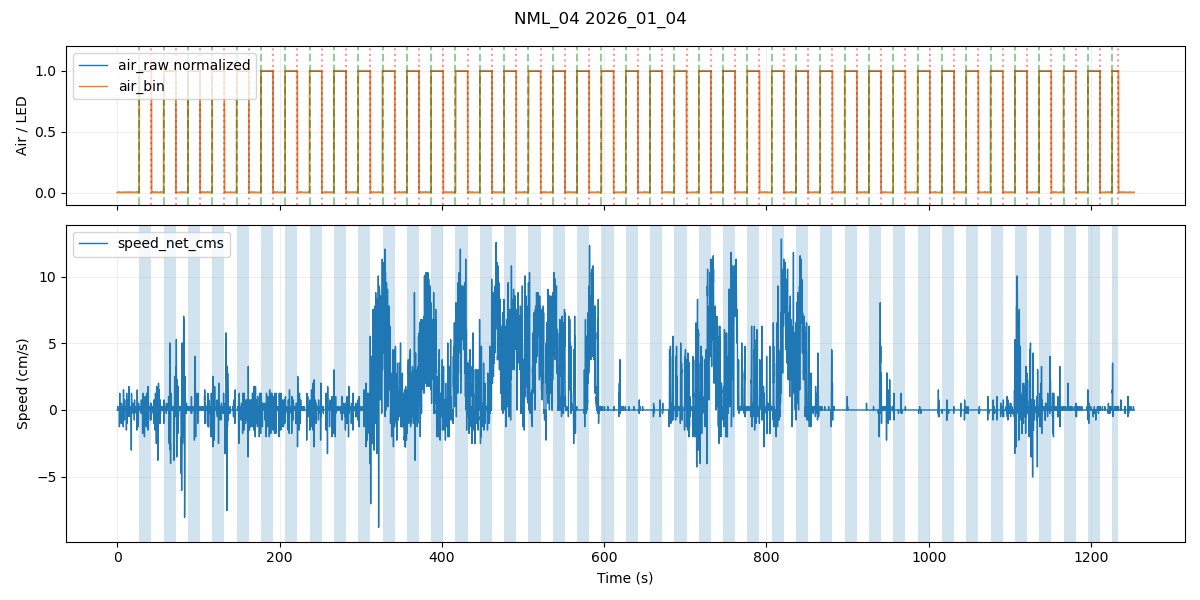

In [24]:
from src.vis.qc_air_edges import plot_event_qc_interactive

animal = "NML_04"
date = "2025_12_27"
date = "2026_01_04"

keys = [
    "t",
    "fs",
    "air_raw",
    "air_bin",
    "Air_r",
    "Air_f",
    "speed_net_cms",
    "speed_path_cms",
]

b = pdio.load_behavior_h5(
    animal,
    date,
    keys=keys
)

fig, axes = plot_event_qc_interactive(
    b,
    speed_key="speed_net_cms",
    plot_fs=50,
    title=f"{animal} {date}"
)

In [27]:
from src.qc.qc_events import make_habituation_led_event_table

animal = "NML_04"
date = "2025_12_27"

led_events = make_habituation_led_event_table(
    animal,
    date,
    min_led_on_s=14.5
)

# 
led_events[~led_events["valid_for_epoch_extraction"]]

,animal,date,phase,event_type,event_number_original,on_idx,off_idx,on_time_s,off_time_s,on_duration_s,valid_for_epoch_extraction,discard_reason
41,NML_04,2025_12_27,habituation,LED_sync_only,41,6504027,6511579,1300.80542,1302.315796,1.510376,False,short_LED_ON_duration_1.51s


In [28]:
from src.qc.qc_events import make_all_habituation_led_event_tables, make_habituation_led_event_table

hab_led_events_all = make_all_habituation_led_event_tables(
    cc_data,
    min_led_on_s=14.5
)

# hab_led_events_all.head()
hab_led_events_all[
    ~hab_led_events_all["valid_for_epoch_extraction"]
][
    [
        "animal",
        "date",
        "event_number_original",
        "on_time_s",
        "off_time_s",
        "on_duration_s",
        "discard_reason"
    ]
]

,animal,date,event_number_original,on_time_s,off_time_s,on_duration_s,discard_reason
41,NML_04,2025_12_27,41,1300.805420,1302.315796,1.510376,short_LED_ON_duration_1.51s
84,NML_04,2025_12_28,42,1391.662231,1406.130249,14.468018,short_LED_ON_duration_14.47s
302,NML_04,2026_01_02,40,NaN,NaN,NaN,missing_duration
385,NML_04,2026_01_04,40,1225.963257,1233.730835,7.767578,short_LED_ON_duration_7.77s
508,NML_04,2026_01_07,41,NaN,NaN,NaN,missing_duration
...,...,...,...,...,...,...,...
2916,NML_08,2026_02_11,40,1245.324219,1247.199829,1.875610,short_LED_ON_duration_1.88s
3002,NML_08,2026_02_15,0,1315.037598,1315.044189,0.006592,short_LED_ON_duration_0.01s
3092,NML_08,2026_02_18,0,10.678400,20.080799,9.402399,short_LED_ON_duration_9.40s
3100,NML_08,2026_02_18,8,796.165588,808.403992,12.238403,short_LED_ON_duration_12.24s


In [30]:
from src.qc.qc_events import (
    build_event_qc_table,
    build_epoch_window_table,
    save_behavior_qc_tables,
    load_behavior_qc_tables,
)

events_df, session_summary_df = build_event_qc_table(
    cc_data,
    drop_first_n=1,
    drop_last_n=1,
    min_hab_led_on_s=14.5,
)

windows_df = build_epoch_window_table(
    events_df,
    window_s=1.0,
)

qc_file = save_behavior_qc_tables(
    events_df,
    session_summary_df,
    windows_df,
    pdata_root=pdata_root,
    filename="behavior_QC.h5",
)

[SAVED] Behavior QC tables: /mnt/pdata/Classical_Conditioning/_cache/behavior_QC.h5


In [31]:
events_df[~events_df["valid_for_epoch_extraction"]][
    [
        "animal",
        "date",
        "phase",
        "event_number",
        "on_duration_s",
        "trial_forward_cm",
        "discard_reason",
    ]
]

,animal,date,phase,event_number,on_duration_s,trial_forward_cm,discard_reason
0,NML_04,2026_01_12,air_training,0,4.870400,6.333451,edge_event_excluded
58,NML_04,2026_01_12,air_training,58,6.954468,14.652388,edge_event_excluded
59,NML_04,2026_01_13,air_training,0,21.984602,16.487078,edge_event_excluded
113,NML_04,2026_01_13,air_training,54,7.924072,7.187964,edge_event_excluded
114,NML_04,2026_01_14,air_training,0,35.012802,12.189379,edge_event_excluded
...,...,...,...,...,...,...,...
8567,NML_08,2026_03_19,tone_air_training,49,6.623535,54.990438,edge_event_excluded
8568,NML_08,2026_03_20,tone_air_training,0,2.158000,20.055928,edge_event_excluded
8615,NML_08,2026_03_20,tone_air_training,47,8.494995,54.990438,edge_event_excluded
8616,NML_08,2026_03_21,tone_air_training,0,2.594600,20.081060,edge_event_excluded


In [32]:
windows_df[~windows_df["valid_window"]][
    [
        "animal",
        "date",
        "phase",
        "event_number",
        "epoch_name",
        "anchor_time_s",
        "invalid_reason",
    ]
]

,animal,date,phase,event_number,epoch_name,anchor_time_s,invalid_reason
0,NML_04,2026_01_12,air_training,0,air_off_center,4.870400,parent_event_invalid
1,NML_04,2026_01_12,air_training,0,air_on_center,0.000000,parent_event_invalid
116,NML_04,2026_01_12,air_training,58,air_off_center,1288.478638,parent_event_invalid
117,NML_04,2026_01_12,air_training,58,air_on_center,1281.524170,parent_event_invalid
118,NML_04,2026_01_13,air_training,0,air_off_center,40.631802,parent_event_invalid
...,...,...,...,...,...,...,...
21001,NML_08,2026_03_21,tone_air_training,0,tone_on_center,9.145000,parent_event_invalid
21190,NML_08,2026_03_21,tone_air_training,48,air_off_center,1223.568604,parent_event_invalid
21191,NML_08,2026_03_21,tone_air_training,48,air_on_center,1216.308350,parent_event_invalid
21192,NML_08,2026_03_21,tone_air_training,48,tone_off_center,1218.308350,parent_event_invalid


In [33]:
windows_df[windows_df["phase"] == "tone_air_training"]["epoch_name"].value_counts()

epoch_name
air_off_center     1932
air_on_center      1932
tone_off_center    1932
tone_on_center     1932
Name: count, dtype: int64